# Phần 4: Phân tích tương quan giữa các biến
**Người thực hiện:** Việt Hoàng

**Mô tả:** Tính hệ số tương quan Pearson và Spearman, vẽ biểu đồ Heatmap và phân tích ý nghĩa thực tiễn.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Cấu hình đường dẫn dữ liệu dùng chung
DATA_PATH = os.path.join('..', 'data', 'processed', 'cleaned_diamonds.csv')
print(DATA_PATH)
df = pd.read_csv(DATA_PATH)


..\data\processed\cleaned_diamonds.csv


In [4]:
df.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Khái niệm về hệ số tương quan

Hệ số tương quan (Correlation Coefficient) là chỉ số dùng để đo lường **mức độ và chiều hướng mối quan hệ giữa hai biến**.

Giá trị của hệ số tương quan thường nằm trong khoảng:

$$
-1 \leq r \leq 1
$$

Trong đó:

- $r > 0$: Hai biến có **tương quan thuận**, tức là khi một biến tăng thì biến còn lại có xu hướng tăng.
- $r < 0$: Hai biến có **tương quan nghịch**, tức là khi một biến tăng thì biến còn lại có xu hướng giảm.
- $r \approx 0$: Hai biến gần như **không có mối quan hệ rõ ràng**.
- $|r|$ càng gần $1$ thì mức độ tương quan giữa hai biến càng mạnh.
- $|r|$ càng gần $0$ thì mức độ tương quan càng yếu.

Trong phân tích dữ liệu, hai hệ số tương quan thường được sử dụng là **Pearson** và **Spearman**.

---

## 1. Hệ số tương quan Pearson

Hệ số tương quan Pearson dùng để đo **mức độ và chiều hướng của mối quan hệ tuyến tính giữa hai biến định lượng**.

### Công thức Pearson

$$
r =
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}{
\sqrt{
\sum_{i=1}^{n}(x_i-\bar{x})^2
\sum_{i=1}^{n}(y_i-\bar{y})^2
}
}
$$

Trong đó:

- $x_i$: Giá trị thứ $i$ của biến $X$.
- $y_i$: Giá trị thứ $i$ của biến $Y$.
- $\bar{x}$: Giá trị trung bình của biến $X$.
- $\bar{y}$: Giá trị trung bình của biến $Y$.
- $n$: Số lượng quan sát.
- $r$: Hệ số tương quan Pearson.

Pearson cũng có thể được biểu diễn thông qua hiệp phương sai:

$$
r =
\frac{
Cov(X,Y)
}{
\sigma_X \sigma_Y
}
$$

Trong đó:

- $Cov(X,Y)$: Hiệp phương sai giữa hai biến $X$ và $Y$.
- $\sigma_X$: Độ lệch chuẩn của biến $X$.
- $\sigma_Y$: Độ lệch chuẩn của biến $Y$.

### Ý nghĩa của hệ số Pearson

Hệ số Pearson có giá trị trong khoảng:

$$
-1 \leq r \leq 1
$$

- $r = 1$: Hai biến có tương quan tuyến tính thuận hoàn hảo.
- $r = -1$: Hai biến có tương quan tuyến tính nghịch hoàn hảo.
- $r = 0$: Không có mối quan hệ tuyến tính giữa hai biến.
- $0 < r < 1$: Tương quan thuận.
- $-1 < r < 0$: Tương quan nghịch.

### Khi nào nên sử dụng Pearson?

Pearson phù hợp khi:

- Hai biến là dữ liệu định lượng.
- Mối quan hệ giữa hai biến có dạng gần tuyến tính.
- Dữ liệu không chứa quá nhiều giá trị ngoại lai nghiêm trọng.
- Các biến có phân phối tương đối phù hợp với các giả định của phương pháp tham số.

Ví dụ trong bộ dữ liệu Diamonds, có thể sử dụng Pearson để kiểm tra mối quan hệ giữa:

- `carat` và `price`
- `x` và `price`
- `y` và `price`
- `z` và `price`

---

## 2. Hệ số tương quan Spearman

Hệ số tương quan Spearman là hệ số dùng để đo **mức độ và chiều hướng của mối quan hệ đơn điệu (monotonic relationship)** giữa hai biến.

Khác với Pearson, Spearman không trực tiếp sử dụng giá trị ban đầu mà chuyển các giá trị thành **thứ hạng (rank)**.

### Công thức Spearman

$$
\rho =
1 -
\frac{
6\sum_{i=1}^{n}d_i^2
}{
n(n^2-1)
}
$$

Trong đó:

- $\rho$: Hệ số tương quan Spearman.
- $d_i$: Hiệu giữa thứ hạng của hai biến tại quan sát thứ $i$.
- $n$: Số lượng quan sát.

Hiệu thứ hạng được tính bằng:

$$
d_i =
Rank(X_i) - Rank(Y_i)
$$

Công thức trên thường được áp dụng trong trường hợp **không có nhiều giá trị đồng hạng (ties)**.

Trong thực tế, Spearman có thể được hiểu là hệ số Pearson được tính trên thứ hạng của hai biến:

$$
\rho =
Corr(Rank(X), Rank(Y))
$$

### Ý nghĩa của hệ số Spearman

Spearman cũng có giá trị trong khoảng:

$$
-1 \leq \rho \leq 1
$$

- $\rho = 1$: Hai biến có mối quan hệ đơn điệu thuận hoàn hảo.
- $\rho = -1$: Hai biến có mối quan hệ đơn điệu nghịch hoàn hảo.
- $\rho = 0$: Không có mối quan hệ đơn điệu rõ ràng.
- $\rho > 0$: Hai biến có xu hướng thay đổi cùng chiều.
- $\rho < 0$: Hai biến có xu hướng thay đổi ngược chiều.

### Khi nào nên sử dụng Spearman?

Spearman phù hợp khi:

- Dữ liệu không tuân theo phân phối chuẩn.
- Mối quan hệ giữa hai biến không tuyến tính nhưng vẫn có xu hướng tăng hoặc giảm rõ ràng.
- Dữ liệu có nhiều giá trị ngoại lai.
- Dữ liệu có dạng thứ bậc (ordinal).
- Pearson có thể không phản ánh tốt mối quan hệ thực tế giữa hai biến.

Do Spearman sử dụng thứ hạng nên nó thường **ít nhạy với outlier hơn Pearson**.

---

### So sánh Pearson và Spearman

| Tiêu chí | Pearson | Spearman |
|---|---|---|
| Ký hiệu | $r$ | $\rho$ hoặc $r_s$ |
| Loại mối quan hệ | Tuyến tính | Đơn điệu |
| Dữ liệu sử dụng | Giá trị gốc | Thứ hạng |
| Dữ liệu định lượng | Phù hợp | Phù hợp |
| Dữ liệu thứ bậc | Không tối ưu | Phù hợp |
| Nhạy với outlier | Cao hơn | Thấp hơn |
| Quan hệ phi tuyến | Không phản ánh tốt | Có thể phản ánh tốt |
| Yêu cầu tuyến tính | Có | Không |





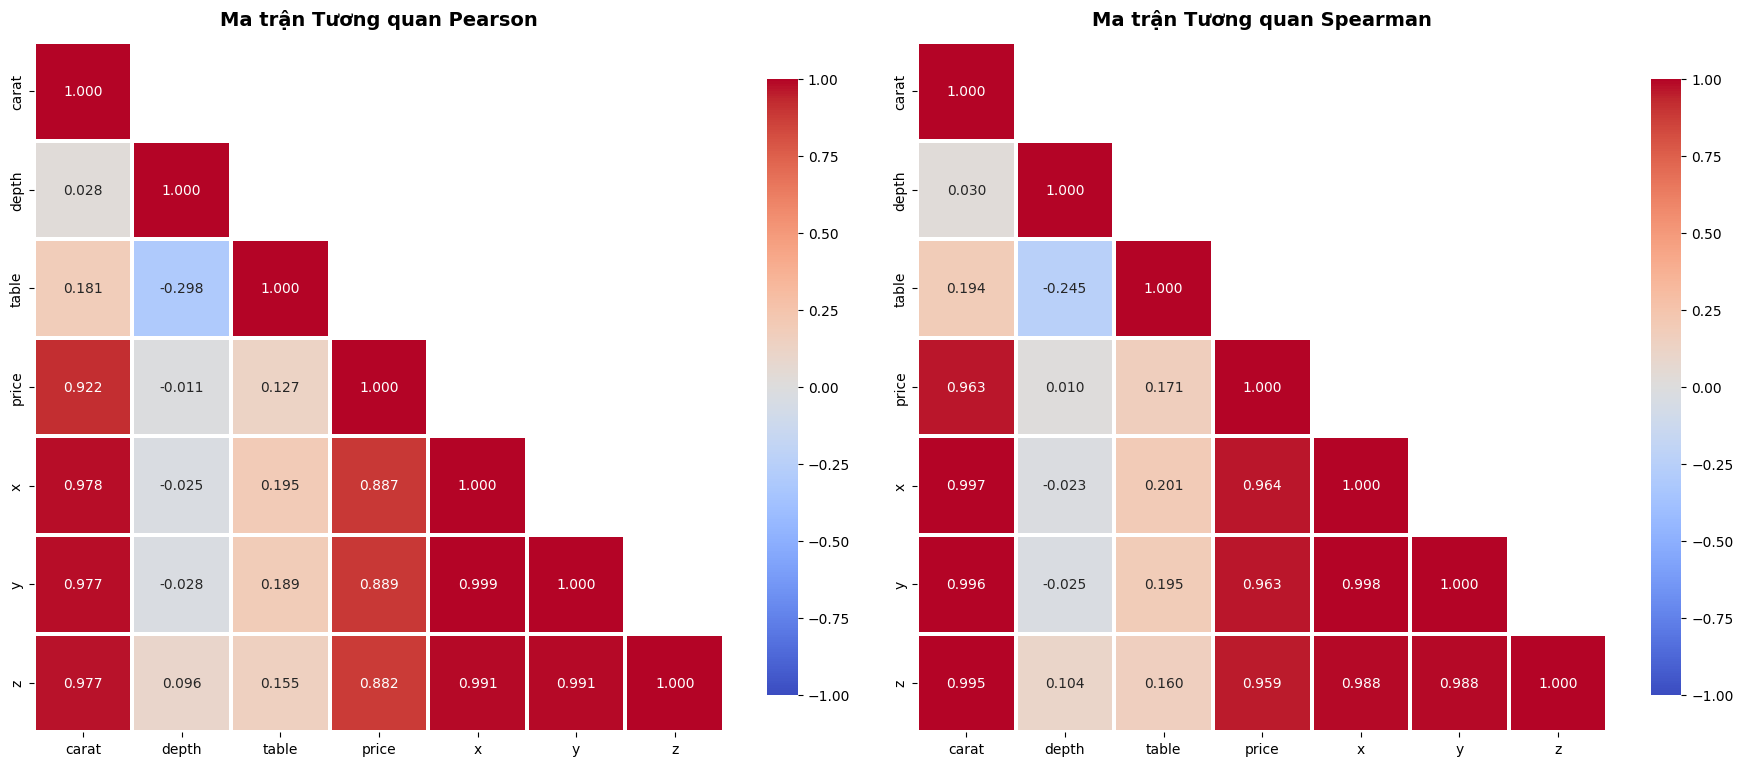

In [5]:
num_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

pearson_corr = df[num_cols].corr(method='pearson')
spearman_corr = df[num_cols].corr(method='spearman')

mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    mask=mask,
    square=True,
    linewidths=1.5,
    cbar_kws={"shrink": .8},
    ax=axes[0]
)
axes[0].set_title("Ma trận Tương quan Pearson", fontsize=14, fontweight='bold', pad=12)
axes[0].grid(False)

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    mask=mask,
    square=True,
    linewidths=1.5,
    cbar_kws={"shrink": .8},
    ax=axes[1]
)
axes[1].set_title("Ma trận Tương quan Spearman", fontsize=14, fontweight='bold', pad=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

In [13]:
comp = pd.DataFrame({
    'Pearson': pearson_corr['price'],
    'Spearman': spearman_corr['price']
}).drop('price')
comp['Chênh lệch (S - P)'] = comp['Spearman'] - comp['Pearson']
comp.sort_values('Spearman', ascending=False).round(3)

,Pearson,Spearman,Chênh lệch (S - P)
x,0.887,0.964,0.077
y,0.889,0.963,0.075
carat,0.922,0.963,0.041
z,0.882,0.959,0.077
table,0.127,0.171,0.044
depth,-0.011,0.010,0.021


 ### Nhận xét

- **Nhóm kích thước/trọng lượng** (`carat`, `x`, `y`, `z`) có tương quan thuận rất mạnh với `price`: Pearson 0.88–0.92, Spearman 0.96–0.96.
- **Spearman cao hơn Pearson** ở mọi cặp với `price` (chênh khoảng 0.04 với `carat`, 0.07–0.08 với `x`, `y`, `z`). Điều này gợi ý mối quan hệ là **đơn điệu nhưng không hoàn toàn tuyến tính**.
- Bốn biến này còn tương quan gần như tuyệt đối với nhau (`x`–`y` = 0.999, `carat`–`x` = 0.978), nên cùng phản ánh một yếu tố là kích thước của viên kim cương.
- `depth` (−0.011) và `table` (0.127) gần như không có tương quan với `price`. Hệ số âm lớn nhất là `depth`–`table` (−0.298), nhưng vẫn ở mức yếu.

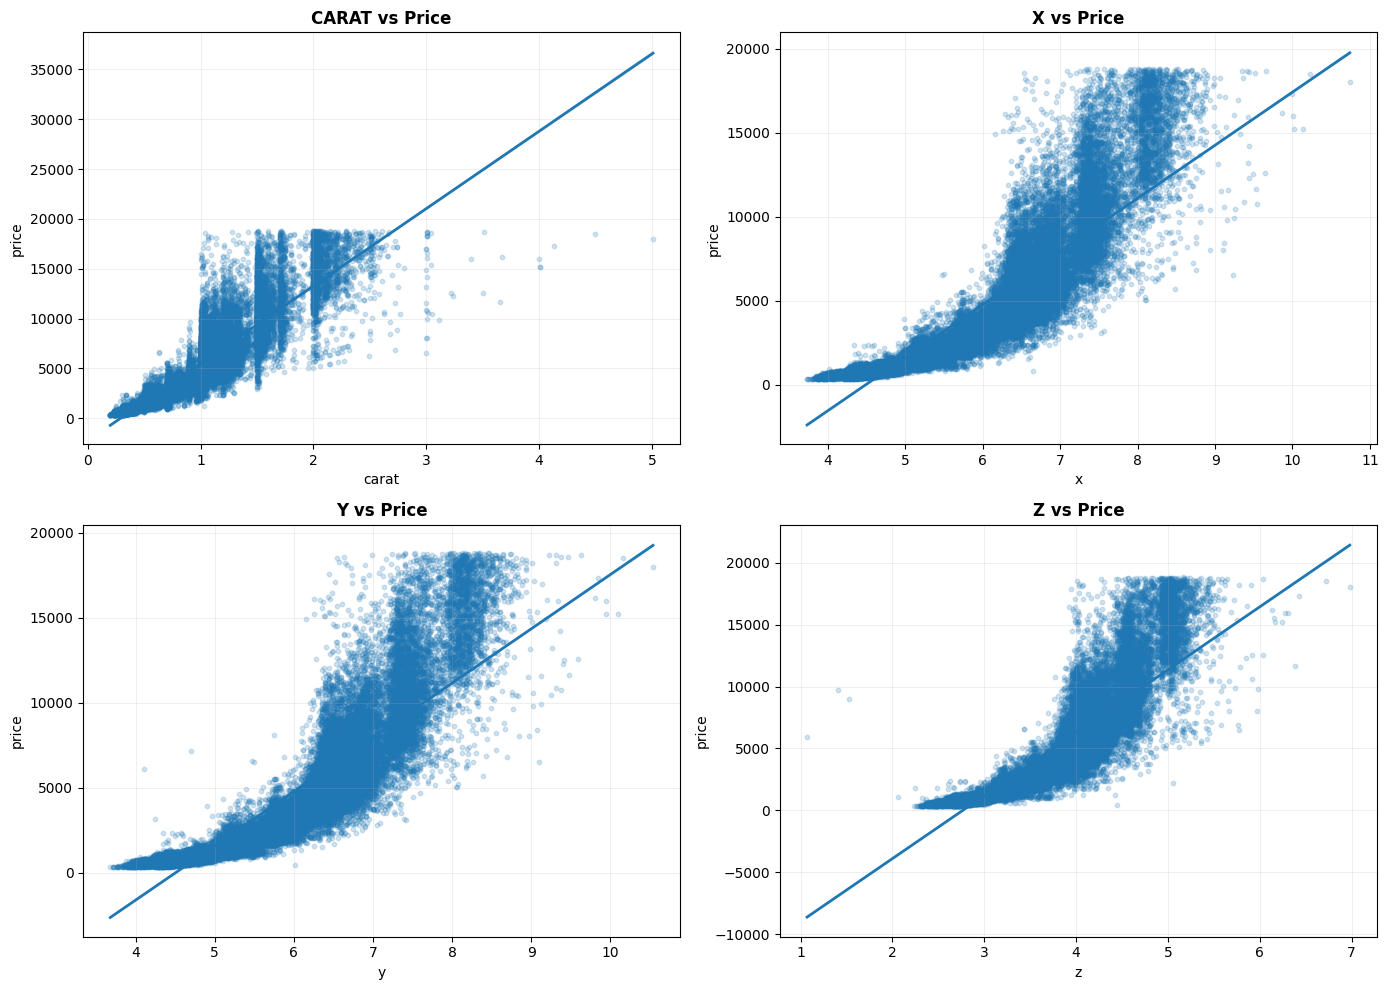

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

strong_pairs = [
    ('carat', 'price'),
    ('x', 'price'),
    ('y', 'price'),
    ('z', 'price')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (x_var, y_var) in zip(axes.flatten(), strong_pairs):
    sns.regplot(
        data=df,
        x=x_var,
        y=y_var,
        scatter_kws={'alpha': 0.2, 's': 10},
        line_kws={'linewidth': 2},
        ax=ax
    )

    ax.set_title(
        f'{x_var.upper()} vs {y_var.capitalize()}',
        fontweight='bold'
    )

    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

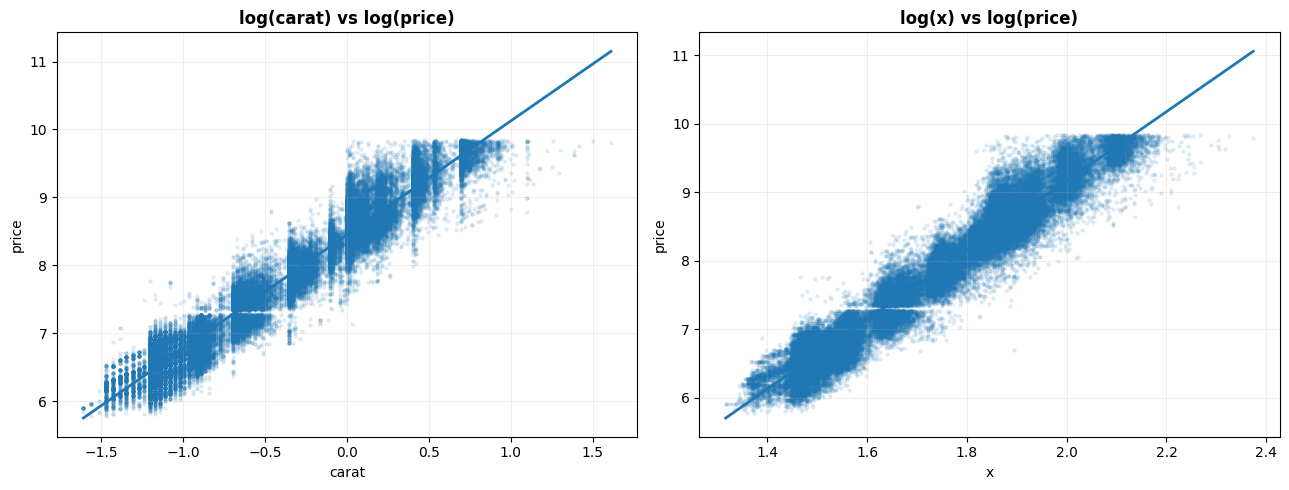

Pearson log(carat) - log(price): 0.966
Pearson log(x) - log(price): 0.966
Pearson log(y) - log(price): 0.966
Pearson log(z) - log(price): 0.961


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, ['carat', 'x']):
    sns.regplot(x=np.log(df[col]), y=np.log(df['price']),
                scatter_kws={'alpha': 0.1, 's': 5}, line_kws={'linewidth': 2}, ax=ax)
    ax.set_title(f'log({col}) vs log(price)', fontweight='bold')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

for col in ['carat', 'x', 'y', 'z']:
    r = np.corrcoef(np.log(df[col]), np.log(df['price']))[0, 1]
    print(f'Pearson log({col}) - log(price): {r:.3f}')

### Nhận xét

- Các điểm có dạng **đường cong** chứ không nằm trên đường thẳng. Đường hồi quy tuyến tính còn dự đoán **giá âm** ở vùng `carat`, `x`, `y`, `z` nhỏ, điều không hợp lý. Đây là lý do Pearson thấp hơn Spearman.
- Độ phân tán tăng dần theo kích thước (hình phễu), tức giá của các viên lớn biến động mạnh hơn.
- `price` bị chặn ở khoảng 18.000 (trần ngang trên đồ thị). Ở `carat` có các cột dọc tại 1.0, 1.5, 2.0 do các mốc trọng lượng phổ biến. Một vài outlier xuất hiện ở `z`.
- Sau khi lấy log hai biến, quan hệ trở nên gần tuyến tính hơn và Pearson tăng từ 0.922 lên ... (với `carat`), củng cố nhận định phi tuyến là nguyên nhân chính.

### Ý nghĩa thực tiễn

1. **Chọn biến cho hồi quy (Phần 5):** `carat`, `x`, `y`, `z` tương quan rất cao với nhau (đa cộng tuyến), nên chỉ nên giữ một đại diện, ưu tiên `carat`.
2. **Biến đổi dữ liệu:** do quan hệ phi tuyến, nên cân nhắc dùng log cho `price` và `carat` khi xây mô hình.
3. **Chọn đúng hệ số:** Spearman phản ánh quan hệ này tốt hơn Pearson.
4. **`depth`, `table`** ít giá trị dự đoán khi xét riêng lẻ.
5. **Lưu ý:** đây là tương quan, chưa phải nhân quả; giá còn chịu ảnh hưởng của `cut`, `color`, `clarity`.